In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

In [6]:
file_path = 'data/category_counts.csv'  # Replace with your actual CSV file path
df = pd.read_csv(file_path)
print(df)

       Recency_bins Frequency_bins               Category  Product_Count
0     (-0.001, 1.0]  (-0.001, 1.0]  ACCESORIOS COSMETICOS              0
1     (-0.001, 1.0]  (-0.001, 1.0]             BIJOUTERIE              0
2     (-0.001, 1.0]  (-0.001, 1.0]           COMPLEMENTOS              0
3     (-0.001, 1.0]  (-0.001, 1.0]       CUIDADO PERSONAL              0
4     (-0.001, 1.0]  (-0.001, 1.0]             FRAGANCIAS              0
...             ...            ...                    ...            ...
1395    (9.0, 10.0]    (9.0, 10.0]     PROMOCION USUARIOS              0
1396    (9.0, 10.0]    (9.0, 10.0]                RELOJES              0
1397    (9.0, 10.0]    (9.0, 10.0]   TRATAMIENTO CORPORAL              0
1398    (9.0, 10.0]    (9.0, 10.0]     TRATAMIENTO FACIAL              0
1399    (9.0, 10.0]    (9.0, 10.0]                 VARIOS              0

[1400 rows x 4 columns]


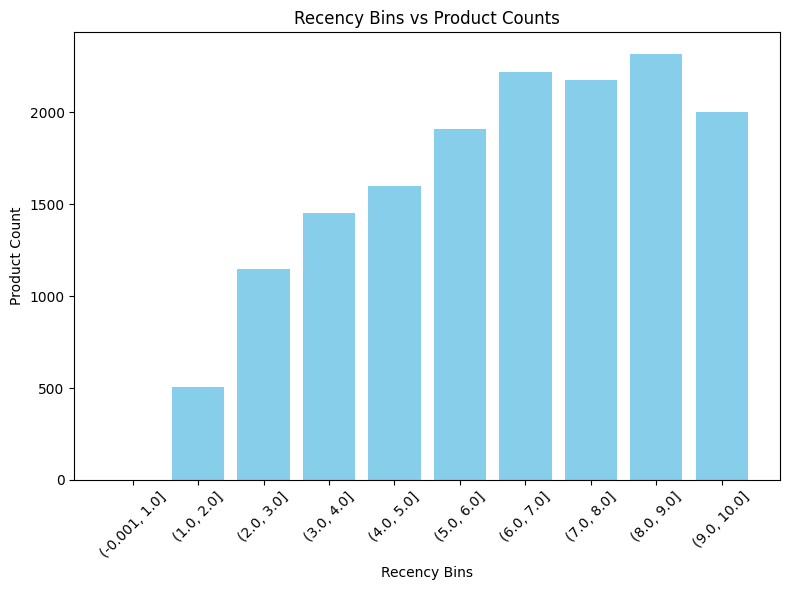

In [14]:
recency_aggegrated = df.groupby('Recency_bins')['Product_Count'].sum().reset_index()

frequency_aggegrated = df.groupby('Frequency_bins')['Product_Count'].sum().reset_index()

# Plot for Recency Bins vs Product Counts
plt.figure(figsize=(8, 6))
plt.bar(recency_aggegrated['Recency_bins'], recency_aggegrated['Product_Count'], color='skyblue')
plt.title('Recency Bins vs Product Counts')
plt.xlabel('Recency Bins')
plt.ylabel('Product Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

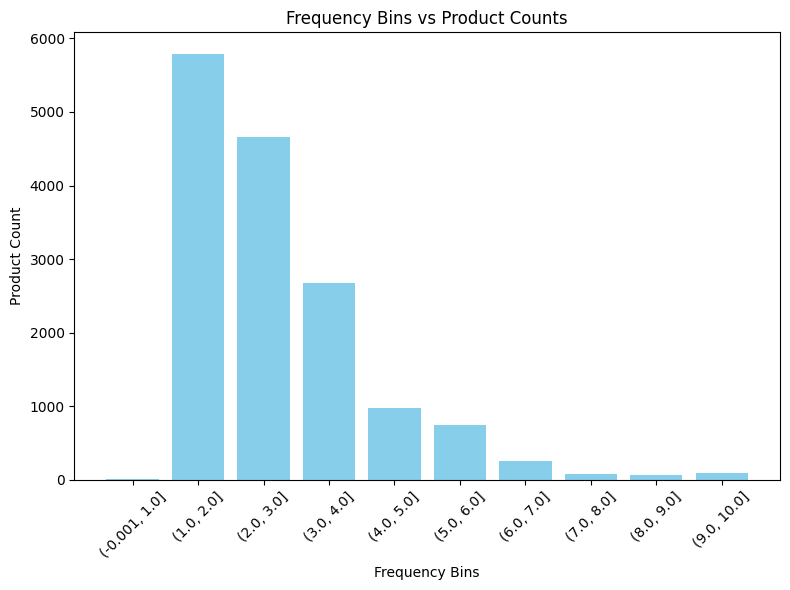

In [17]:
# Plot for Recency Bins vs Product Counts
plt.figure(figsize=(8, 6))
plt.bar(frequency_aggegrated['Frequency_bins'], frequency_aggegrated['Product_Count'], color='skyblue')
plt.title('Frequency Bins vs Product Counts')
plt.xlabel('Frequency Bins')
plt.ylabel('Product Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# Function to calculate entropy
def calculate_entropy(data):
    # Ensure data is numeric (convert if necessary)
    data = pd.to_numeric(data, errors='coerce')
    
    # Filter out NaN values
    data = data.dropna()

    # Normalize the data (probabilities)
    probabilities = data / data.sum()

    # Filter out zero probabilities to avoid log issues
    probabilities = probabilities[probabilities > 0]

    # Calculate entropy
    entropy = -np.sum(probabilities * np.log(probabilities))
    return entropy

# Calculate entropy for Frequency_bins and Recency_bins
frequency_entropy = calculate_entropy(frequency_aggegrated['Product_Count'])
recency_entropy = calculate_entropy(recency_aggegrated['Product_Count'])

# Calculate weights
total_entropy = frequency_entropy + recency_entropy
alpha = frequency_entropy / total_entropy
beta = recency_entropy / total_entropy

# Display results
print(f"Frequency Entropy: {frequency_entropy:.2f}")
print(f"Recency Entropy: {recency_entropy:.2f}")
print(f"Alpha: {alpha:.4f}")
print(f"Beta: {beta:.4f}")


Frequency Entropy: 1.51
Recency Entropy: 2.13
Alpha: 0.4142
Beta: 0.5858


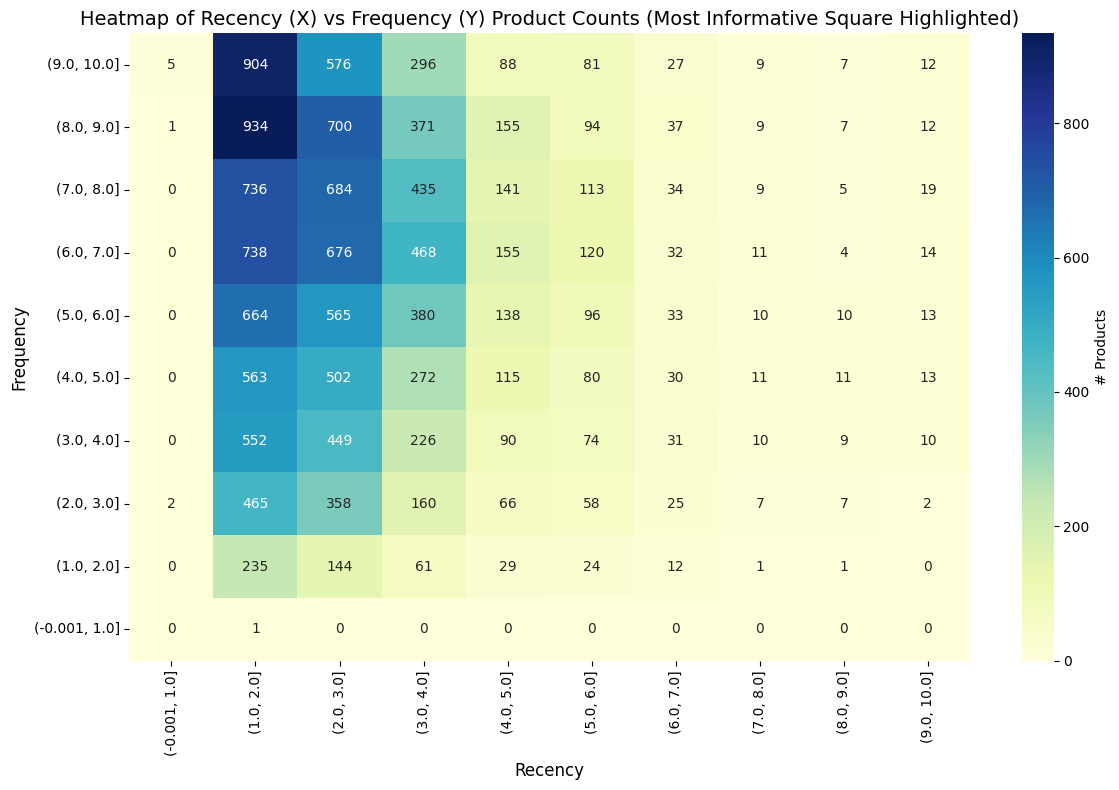

In [29]:
import seaborn as sns

# Aggregate product_count by Recency_bins and Frequency_bins
heatmap_data = df.pivot_table(values='Product_Count', 
                              index='Recency_bins', 
                              columns='Frequency_bins', 
                              aggfunc='sum', fill_value=0)

# Plot heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="YlGnBu", cbar_kws={'label': '# Products'})
plt.gca().invert_yaxis()  # Invert the y-axis for consistency

plt.title('Heatmap of Recency (X) vs Frequency (Y) Product Counts (Most Informative Square Highlighted)', fontsize=14)
plt.xlabel('Recency', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()
